# Motion tuning

This notebook generates the plots for Supp Figures 9 & 10. All plots use the retinal model trained for prediction. The pre-trained model can either be downloaded from this repo or can be trained from scatch (see README).

In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import torch
import pandas as pd
import numpy as np
import pickle
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import wilcoxon

from brainbox import tuning
from retina import train, analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
root = os.path.abspath(".") if os.path.exists("setup.py") else os.path.abspath("..")

In [3]:
model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")

In [4]:
torch.manual_seed(0)
grating_query = analysis.GratingQuery(root, model, ablate_recurrence=False)

## Supp Fig 9 Object motion sensitivity to jittered motion

In [5]:
display_tuning = False
torch.manual_seed(0)
grating_query = analysis.GratingQuery(root, model, ablate_recurrence=False)
query = tuning.TuningQuery(f"{root}/data/tuning/rec_ablate_False")
tuning_df = query.validate(response_threshold=0.05, fit_threshold=0.0)

pd.set_option('display.max_rows', None)  
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)  
pd.set_option('display.max_colwidth', None)  

if display_tuning:
    tuning_df

In [6]:
display_rfs = False
torch.manual_seed(0)
rf_query = analysis.RFQuery(root, model)
if display_rfs:
    rf_query.params_df

INFO:util:Processing batch 0 out of 4...
INFO:util:Processing batch 1 out of 4...
INFO:util:Processing batch 2 out of 4...
INFO:util:Processing batch 3 out of 4...
INFO:gaussian:CC criteria exclusion 219
INFO:gaussian:Location criteria exclusion 38
INFO:gaussian:Envelope criteria exclusion 12


In [7]:
def plot_grating_and_raster(title, grating, raster_x, raster_y, ax_grating, ax_raster, probe_ms=3000):
    ax_grating.imshow(grating, cmap="Greys", vmin=-1, vmax=1)
    ax_raster.scatter(raster_x, raster_y+1, s=1, c="black")
    ax_grating.set_title(title, fontsize=14, pad=8)
    ax_grating.set_xticks([])
    ax_grating.set_yticks([])
    ax_grating.spines["top"].set_linewidth(2)
    ax_grating.spines["bottom"].set_linewidth(2)
    ax_grating.spines["left"].set_linewidth(2)
    ax_grating.spines["right"].set_linewidth(2)
    
    ax_raster.spines["top"].set_visible(False)
    ax_raster.spines["right"].set_visible(False)
    ax_raster.spines["bottom"].set_linewidth(2)
    ax_raster.spines["left"].set_linewidth(2)
    ax_raster.xaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax_raster.yaxis.set_tick_params(width=3, labelsize=14, pad=8)
    ax_raster.set_yticks([1, 8])
    ax_raster.set_xticks([0, 240, 480, 720, 960, 1200, 1440, 1680, 1920, 2160, 2400])
    ax_raster.set_xticklabels([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    ax_raster.set_xlabel("Time (s)", fontsize=14, labelpad=8)
    ax_raster.set_ylabel("Trial", fontsize=14, labelpad=2)

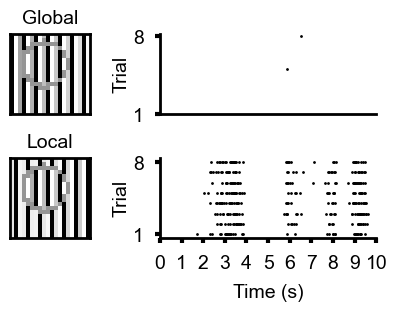

In [8]:
torch.manual_seed(0)
ratio = []
activity = []
cell_type = []
spatial_freq = 0.33
temporal_freq = 3
radius = 3
luminance = 1.5
probe_ms = 10000
xy0min = -1
xy0max = 20
select_cells = range(400)
select_cells = [214]

for n in select_cells:
    torch.manual_seed(0)
    
    rfvec = rf_query.params_df.og_index==n
    tunvec = tuning_df.index==n
    if any(rfvec):

        theta = tuning_df.loc[tunvec, 'theta'].iloc[0]
        sf    = tuning_df.loc[tunvec, 'sf'].iloc[0]
        tf    = tuning_df.loc[tunvec, 'tf'].iloc[0]
        x0    = rf_query.params_df.loc[rfvec, 'x0'].iloc[0]
        y0    = rf_query.params_df.loc[rfvec, 'y0'].iloc[0]
        rfsize = np.sqrt(rf_query.params_df.loc[rfvec, 'size'].iloc[0])
        differential_motion = analysis.JitteredDifferentialMotion(model, unit_idx=n, theta=0, spatial_freq=spatial_freq,
                                                          temporal_freq=temporal_freq, y0=y0, x0=x0, r=5,
                                                          lum=luminance, probe_ms=probe_ms, moving_background=True,
                                                          ablate_recurrence=False)

        fig = plt.figure(constrained_layout=True, figsize=(4, 3))
        spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig)
        ax1 = fig.add_subplot(spec[0, :2])
        ax2 = fig.add_subplot(spec[0, 2:]) 
        ax3 = fig.add_subplot(spec[1, :2])
        ax4 = fig.add_subplot(spec[1, 2:])

        plot_grating_and_raster("Global", differential_motion.masked_grating_global[1000],
                                *differential_motion.global_raster, ax1, ax2, probe_ms)
        ax2.set_xticks([])
        ax2.set_xlabel("")
        plot_grating_and_raster("Local", differential_motion.masked_grating_local[1000],
                                *differential_motion.local_raster, ax3, ax4, probe_ms)
        
        plt.savefig(f"{root}/figures/fig4/motion_selectivity_raster.svg", format="svg",
                    transparent=False, bbox_inches="tight")
        
        if differential_motion.local_raster[0].size>0:
            ratio.append(differential_motion.global_raster[0].size/differential_motion.local_raster[0].size)
        else:
            if differential_motion.global_raster[0].size>0:
                ratio.append(10)
            else:
                ratio.append(100)
        activity.append(differential_motion.global_raster[0].size + differential_motion.local_raster[0].size)
        cell_type.append(rf_query.params_df.loc[rfvec, 'type'].iloc[0])
        plt.savefig(f"{root}/figures/supp/jittered_object_motion.svg", format="svg", transparent=False, bbox_inches="tight")

In [9]:
#This can take a day or more to run, better to just load pre-run version

loadfile = True
    
if not loadfile:

    spatial_freq = 0.33
    temporal_freq = 3
    radius = 3
    luminance = 1.5
    xy0min = -1
    xy0max = 20

    plot_results = False
    num = 10
    ratio = [[] for _ in range(num)]
    osmi = [[] for _ in range(num)]
    activity = [[] for _ in range(num)]
    cell_type= [[] for _ in range(num)]
    global_spikes = [[] for _ in range(num)]
    local_spikes = [[] for _ in range(num)]
    ratio_ablate = [[] for _ in range(num)]
    osmi_ablate = [[] for _ in range(num)]
    activity_ablate = [[] for _ in range(num)]
    cell_type_ablate= [[] for _ in range(num)]
    global_spikes_ablate = [[] for _ in range(num)]
    local_spikes_ablate = [[] for _ in range(num)]

    for nr in range(num):
        print("repeat number")
        print(nr)

        torch.manual_seed(0+4*nr)

        for n in range(400):

            rfvec = rf_query.params_df.og_index==n
            if any(rfvec):
                x0 = rf_query.params_df.loc[rfvec, 'x0'].iloc[0]
                y0 = rf_query.params_df.loc[rfvec, 'y0'].iloc[0]
                if xy0min < x0 < xy0max and xy0min < y0 < xy0max: 
                    
                    torch.manual_seed(0+4*nr)
                    differential_motion = analysis.JitteredDifferentialMotion(model, unit_idx=n, theta=0, 
                                                                      spatial_freq=spatial_freq,
                                                                      temporal_freq=temporal_freq,
                                                                      y0=y0, x0=x0, r=radius,
                                                                      lum=luminance, moving_background=True,
                                                                      ablate_recurrence=False)
                    torch.manual_seed(0+4*nr)
                    differential_motion_ablate = analysis.JitteredDifferentialMotion(model, unit_idx=n, theta=0, 
                                                                      spatial_freq=spatial_freq,
                                                                      temporal_freq=temporal_freq,
                                                                      y0=y0, x0=x0, r=radius,
                                                                      lum=luminance, moving_background=True,
                                                                      ablate_recurrence=True)

                    local_spikes_temp = differential_motion.local_raster[0].size
                    global_spikes_temp = differential_motion.global_raster[0].size
                    local_spikes_ablate_temp = differential_motion_ablate.local_raster[0].size
                    global_spikes_ablate_temp = differential_motion_ablate.global_raster[0].size
                    local_spikes[nr].append(local_spikes_temp)
                    global_spikes[nr].append(global_spikes_temp)
                    local_spikes_ablate[nr].append(local_spikes_ablate_temp)
                    global_spikes_ablate[nr].append(global_spikes_ablate_temp)

                    if local_spikes_temp>0:
                        ratio_temp = global_spikes_temp/local_spikes_temp
                    else:
                        if global_spikes_temp>0:
                            ratio_temp = np.nan
                        else:
                            ratio_temp = 1
                    ratio[nr].append(ratio_temp)

                    if local_spikes_ablate_temp>0:
                        ratio_ablate_temp = global_spikes_ablate_temp/local_spikes_ablate_temp
                    else:
                        if global_spikes_ablate_temp>0:
                            ratio_ablate_temp = np.nan
                        else:
                            ratio_ablate_temp = 1
                    ratio_ablate[nr].append(ratio_ablate_temp)

                    if (local_spikes_temp +
                        global_spikes_temp)>0:
                        osmi_temp = (local_spikes_temp -
                                     global_spikes_temp) / \
                                    (local_spikes_temp +
                                     global_spikes_temp)
                    else:
                        osmi_temp = 0                            
                    osmi[nr].append(osmi_temp)          

                    if (local_spikes_ablate_temp +
                        global_spikes_ablate_temp)>0:
                        osmi_ablate_temp = (local_spikes_ablate_temp -
                                     global_spikes_ablate_temp) / \
                                    (local_spikes_ablate_temp +
                                     global_spikes_ablate_temp)
                    else:
                        osmi_ablate_temp = 0                            
                    osmi_ablate[nr].append(osmi_ablate_temp)         

                    activity[nr].append(global_spikes_temp+local_spikes_temp)
                    cell_type[nr].append(rf_query.params_df.loc[rfvec, 'type'].iloc[0])

                    if plot_results:
                        fig = plt.figure(constrained_layout=True, figsize=(4, 3))
                        spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig)
                        ax1 = fig.add_subplot(spec[0, :2])
                        ax2 = fig.add_subplot(spec[0, 2:]) 
                        ax3 = fig.add_subplot(spec[1, :2])
                        ax4 = fig.add_subplot(spec[1, 2:])

                        plot_grating_and_raster("Global", differential_motion.masked_grating_global[420-40],
                                                *differential_motion.global_raster, ax1, ax2)
                        ax2.set_xticks([])
                        ax2.set_xlabel("")
                        ratio_temp_3sf = f"{ratio_temp:.3g}"
                        osmi_temp_3sf = f"{osmi_temp:.3g}"
                        ax2.set_title(f"{global_spikes_temp}, {ratio_temp_3sf}, {osmi_temp_3sf}", fontsize=16)

                        plot_grating_and_raster("Local", differential_motion.masked_grating_local[420-40],
                                                *differential_motion.local_raster, ax3, ax4)
                        ax4.set_title(str(differential_motion.local_raster[0].size),fontsize=16)

                        fig = plt.figure(constrained_layout=True, figsize=(4, 3))
                        spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig)
                        ax1 = fig.add_subplot(spec[0, :2])
                        ax2 = fig.add_subplot(spec[0, 2:]) 
                        ax3 = fig.add_subplot(spec[1, :2])
                        ax4 = fig.add_subplot(spec[1, 2:])

                        plot_grating_and_raster("Global", differential_motion_ablate.masked_grating_global[420-40],
                                                *differential_motion_ablate.global_raster, ax1, ax2)
                        ax2.set_xticks([])
                        ax2.set_xlabel("")
                        ratio_ablate_temp_3sf = f"{ratio_ablate_temp:.3g}"
                        osmi_ablate_temp_3sf = f"{osmi_ablate_temp:.3g}"
                        ax2.set_title(f"{global_spikes_ablate_temp}, {ratio_ablate_temp_3sf}, {osmi_ablate_temp_3sf}", fontsize=16)

                        plot_grating_and_raster("Local", differential_motion_ablate.masked_grating_local[420-40],
                                                *differential_motion_ablate.local_raster, ax3, ax4)
                        ax4.set_title(str(differential_motion_ablate.local_raster[0].size),fontsize=16)



In [10]:
# Load old file if needed

tuning_folder = os.path.join(root, "data", "tuning")

loadfile = True#
verbose = False

if loadfile:
    
    class SafeUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            missing_functions = {
                'plot_XS_units',
                'plot_orientation_tuning',
                'plot_grating_and_raster',
                'get_stats',
                'flatten_stats',
                'interleave',
                'mean_and_sem',
            }
            if name in missing_functions:
                if verbose:
                    print(f"Replacing missing function '{name}' with a dummy.")
                return lambda *args, **kwargs: None
            return super().find_class(module, name)

    filename = os.path.join(tuning_folder, "Fig4variables_26Jul2025_tight3_ring1_240Hz_all_10repeats_200seconds_good_short.pkl")

    with open(filename, "rb") as f:
        loaded_vars = SafeUnpickler(f).load()

    globals().update(loaded_vars)

In [11]:
osmia_all = np.array(osmi)                
activitya_all = np.array(activity)
osmia_ablate_all = np.array(osmi_ablate)

mean_activity = np.mean(activitya_all, axis=0)
active_mask = mean_activity > 10

osmia_active = osmia_all[:, active_mask]
osmia_ablate_active = osmia_ablate_all[:, active_mask]

def mean_and_sem(data):
    mean = np.mean(data, axis=0) 
    sem = np.std(data, axis=0, ddof=1) / np.sqrt(data.shape[0])
    return np.mean(mean), np.mean(sem)  

osmi_mean, osmi_sem = mean_and_sem(osmia_active)
osmi_ablate_mean, osmi_ablate_sem = mean_and_sem(osmia_ablate_active)

print("\nMean ± SEM across repeats (active units only):")
print(f"OMSI Intact:   {osmi_mean:.3f} ± {osmi_sem:.3f}")
print(f"OMSI Ablated:  {osmi_ablate_mean:.3f} ± {osmi_ablate_sem:.3f}")

osmi_intact_per_repeat = np.mean(osmia_active, axis=1)
osmi_ablated_per_repeat = np.mean(osmia_ablate_active, axis=1)

w_stat, p_val = wilcoxon(osmi_intact_per_repeat, osmi_ablated_per_repeat)
print(f"\nWilcoxon signed-rank test: W = {w_stat:.3f}, p = {p_val:.4f}")



Mean ± SEM across repeats (active units only):
OMSI Intact:   0.112 ± 0.026
OMSI Ablated:  0.104 ± 0.027

Wilcoxon signed-rank test: W = 1.000, p = 0.0039


In [12]:
# Save results if needed

save_results = False
save_mode = 'short'  

short_vars = ['osmi', 'osmi_ablate', 'activity']  

root = os.path.abspath(".") if os.path.exists("setup.py") else os.path.abspath("..")
save_folder = os.path.join(root, "data", "tuning")

if save_results:
    
    variables = []
    for name, val in list(globals().items()):
        if not name.startswith("_"):
            try:
                size = sys.getsizeof(val)
                variables.append((name, type(val).__name__, size))
            except:
                pass  

    variables.sort(key=lambda x: x[2], reverse=True)

    to_save = {}
    for k, v in list(globals().items()):
        if k.startswith("_") or k == "f":
            continue
        try:
            pickle.dumps(v)  
            to_save[k] = v
        except (pickle.PicklingError, AttributeError, TypeError):
            pass  

    base_file = os.path.join(save_folder, "Fig4variables_26Jul2025_tight3_ring1_240Hz_all_10repeats_200seconds_good.pkl")

    if save_mode == 'full':
        with open(base_file, "wb") as f:
            pickle.dump(to_save, f)
        print(f"Full pickle saved as: {base_file}")
    elif save_mode == 'short':
        short_file = base_file.replace(".pkl", "_short.pkl")
        to_save_short = {k: v for k, v in to_save.items() if k in short_vars}
        with open(short_file, "wb") as f:
            pickle.dump(to_save_short, f)
        print(f"Short pickle saved as: {short_file}")
    else:
        print("Invalid save_mode. Choose 'full' or 'short'.")

## Supp Fig 10 Population anticipation responses

In [13]:
plt.rcParams.update({ 
    'font.size': 20,
    'lines.linewidth': 2.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2.0
})

def gaussian_smooth_to_even_grid(x, y, sigma=2, num_points=500, x_min=0, x_max=19):

    x = np.asarray(x)
    y = np.asarray(y)
    
    if x_min is None:
        x_min = np.min(x)
    if x_max is None:
        x_max = np.max(x)

    x_new = np.linspace(x_min, x_max, num_points)
    y_smooth = np.zeros_like(x_new)

    def gaussian_kernel(xi, x_all, sigma):
        """Gaussian kernel function."""
        return np.exp(-0.5 * ((x_all - xi) / sigma) ** 2)

    for i, xi in enumerate(x_new):
        weights = gaussian_kernel(xi, x, sigma)

        y_smooth[i] = np.sum(weights * y)

    return x_new, y_smooth

Relative, Speed 0.125 pixels/frame, Rel. Posit. 0.3236472945891773


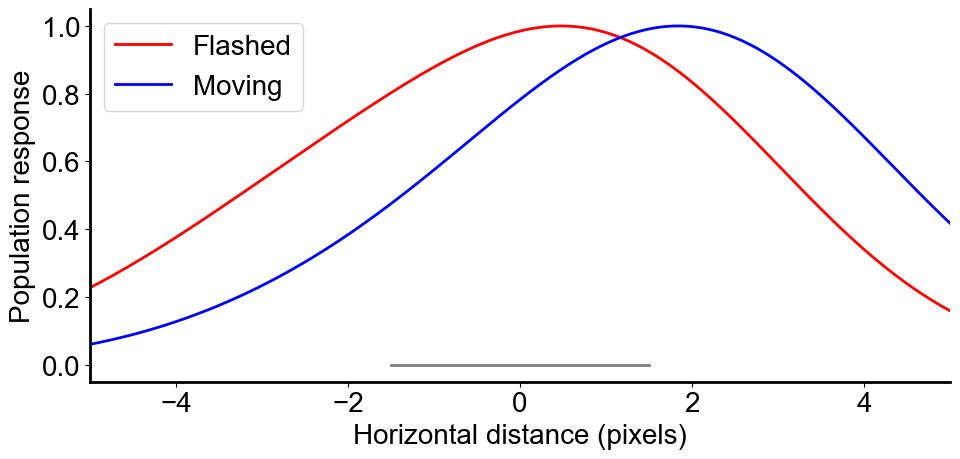

In [14]:
bar_speeds = []
max_positions = []
bar_width = 3
bar_x0s = np.array([11,12,13,14], dtype=int)
bar_speeds = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20], dtype=int)
response_window = 3
response_window_flash = 1
start_early = 1
max_positions = np.zeros((bar_x0s.size, bar_speeds.size))
rel_max_positions = np.zeros((bar_speeds.size))
rel_x0 = []
rel_flash_response = []
rel_move_response = []
plot_per_position = False
plot_relative_response = False
plot_select_response = 8
add_title = False
ablate_recurrence=False
sigma = 2
fontsize = 20

for j, speedi in enumerate(bar_speeds):
    
    rel_x0 = []
    rel_flash_response = []
    rel_move_response = []
    for i, bar_x0 in enumerate(bar_x0s):
        
        torch.manual_seed(0)
        ant = analysis.anticipation.AnticipationAnalysis(model, bar_width=bar_width, bar_x0=bar_x0, luminance=0,
                                                         ablate_recurrence=ablate_recurrence, bar_speed=speedi,
                                                         smooth=True)
        x0list = []
        y0list = []
        flash_response = []
        move_response = []

        for n in range(400):
            rfvec = rf_query.params_df.og_index==n
            tunvec = tuning_df.index==n
            if any(rfvec) and (rf_query.params_df[rfvec].type.item()==1):

                x0 = rf_query.params_df[rfvec].x0.item()
                y0 = rf_query.params_df[rfvec].y0.item()
                x0list.append(x0)
                y0list.append(y0)
               
                flash_response.append(ant.mean_flash_bar_firing[n,:].numpy())
                move_response.append(ant.mean_right_moving_bar_firing[n,:].numpy())
                    
        x0a = np.array(x0list)
        y0a = np.array(y0list)
        flash_responsea = np.array(flash_response)
        move_responsea = np.array(move_response)

        r_window = min(response_window,speedi)
        r_window_flash = min(response_window_flash,speedi)
        x_new_flash, y_smooth_flash = gaussian_smooth_to_even_grid(x0a,
                                                                   np.mean(
                                                                       flash_responsea[:,
                                                                                       100:(100+r_window_flash)],
                                                                       axis=1),sigma=sigma)
        x_new_move, y_smooth_move = gaussian_smooth_to_even_grid(x0a,
                                                                 np.mean(
                                                                     move_responsea[:,
                                                                                    (100-start_early):(100-start_early+r_window)],
                                                                     axis=1), sigma=sigma)
        
        

        rel_x0.append(x0a - (bar_x0 + np.floor(bar_width/2)))
        rel_flash_response.append(np.mean(flash_responsea[:, 100:(100+r_window_flash)],axis=1))
        rel_move_response.append(np.mean(move_responsea[:, (100-start_early):(100-start_early+r_window)],axis=1))
        
        max_position = x_new_move[np.argmax(y_smooth_move)] 
        max_peak = np.max(y_smooth_move)

        max_positions[i,j] = max_position - (bar_x0 + bar_width - 0.5)
        
        if plot_per_position:
            plt.figure(figsize=(10, 5))

            plt.plot(x_new_flash, y_smooth_flash, label='flashed', linewidth=2, color='red')

            plt.plot(x_new_move, y_smooth_move, label='moving', linewidth=2, color='blue')
            max_position = x_new_move[np.argmax(y_smooth_move)] 
            max_peak = np.max(y_smooth_move)

            plt.plot([bar_x0,bar_x0+0.5,bar_x0+2.5],[0,0,0],linewidth=2,color='gray')

            plt.title(f"Speed {1/speedi} pixels/frame, bar x0 {bar_x0}",fontsize=fontsize)
            plt.xlabel('Horizontal distance (pixels)',fontsize=fontsize)
            plt.ylabel('Response',fontsize=fontsize)
            plt.tick_params(axis='both', labelsize=fontsize) 

            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            plt.gca().spines['top'].set_visible(False)
            plt.gca().spines['right'].set_visible(False)

    rel_x0 = np.array(rel_x0)
    rel_flash_response = np.array(rel_flash_response)
    rel_move_response = np.array(rel_move_response)
        
    x_new_flash, y_smooth_flash = gaussian_smooth_to_even_grid(rel_x0,rel_flash_response, x_min=-10, x_max=10,
                                                               sigma=sigma)
    x_new_move, y_smooth_move = gaussian_smooth_to_even_grid(rel_x0,rel_move_response, x_min=-10, x_max=10,
                                                             sigma=sigma)
    rel_max_position = x_new_move[np.argmax(y_smooth_move)] -1.5
    rel_max_peak = np.max(y_smooth_move)

    rel_max_positions[j] = rel_max_position#NH, 1 to 1.5
        
    if plot_relative_response or (plot_select_response==speedi):
        fig = plt.figure(figsize=(10, 5))

        plt.plot(x_new_flash, y_smooth_flash/y_smooth_flash.max(), label='Flashed', linewidth=2, color='red')

        plt.plot(x_new_move, y_smooth_move/y_smooth_move.max(), label='Moving', linewidth=2, color='blue')
        plt.plot([-1.5,0,1.5],[0,0,0],linewidth=2,color='gray')

        if add_title:
            ax = plt.title(f"Relative, Speed {1/speedi} pixels/frame, Rel. Posit. {rel_max_position}",fontsize=fontsize)
        else:
            print(f"Relative, Speed {1/speedi} pixels/frame, Rel. Posit. {rel_max_position}")
        plt.xlabel('Horizontal distance (pixels)',fontsize=fontsize)
        plt.ylabel('Population response',fontsize=fontsize)
        plt.tick_params(axis='both', labelsize=fontsize)
        plt.grid(False)  
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.legend(fontsize=fontsize) 
        
        plt.legend()
        plt.grid(False)
        plt.xlim(-5, 5) #NH
        plt.tight_layout()
        fig.savefig(f"{root}/figures/supp/anticipation_population.svg", transparent=False, bbox_inches="tight")
        plt.show()



In [15]:
bar_speeds_ablate = []
max_positions_ablate = []
bar_width = 3
bar_x0s = np.array([11,12,13,14], dtype=int)
bar_speeds = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20], dtype=int)
response_window = 3
response_window_flash = 1
start_early = 1
max_positions_ablate = np.zeros((bar_x0s.size, bar_speeds.size))
rel_max_positions_ablate = np.zeros((bar_speeds.size))
rel_x0_ablate = []
rel_flash_response_ablate = []
rel_move_response_ablate = []
plot_per_position = False
plot_relative_response = False
plot_select_response = -1
add_title = False
ablate_recurrence=True
sigma = 2
fontsize = 20

for j, speedi in enumerate(bar_speeds):
    rel_x0_ablate = []
    rel_flash_response_ablate = []
    rel_move_response_ablate = []
    for i, bar_x0 in enumerate(bar_x0s):
        

        torch.manual_seed(0)
        torch.manual_seed(0)
        ant = analysis.anticipation.AnticipationAnalysis(model, bar_width=bar_width, bar_x0=bar_x0, luminance=0,
                                                         ablate_recurrence=ablate_recurrence, bar_speed=speedi,
                                                         smooth=True)
        x0list = []
        y0list = []
        flash_response = []
        move_response = []

        for n in range(400):
            rfvec = rf_query.params_df.og_index==n
            tunvec = tuning_df.index==n
            if any(rfvec) and (rf_query.params_df[rfvec].type.item()==1):

                x0 = rf_query.params_df[rfvec].x0.item()
                y0 = rf_query.params_df[rfvec].y0.item()
                x0list.append(x0)
                y0list.append(y0)

           
                flash_response.append(ant.mean_flash_bar_firing[n,:].numpy())
                move_response.append(ant.mean_right_moving_bar_firing[n,:].numpy())
                    
        x0a = np.array(x0list)
        y0a = np.array(y0list)
        flash_responsea = np.array(flash_response)
        move_responsea = np.array(move_response)

        r_window = min(response_window,speedi)
        r_window_flash = min(response_window_flash,speedi)
        x_new_flash, y_smooth_flash = gaussian_smooth_to_even_grid(x0a,
                                                                   np.mean(
                                                                       flash_responsea[:,
                                                                                       100:(100+r_window_flash)],
                                                                       axis=1),sigma=sigma)
        x_new_move, y_smooth_move = gaussian_smooth_to_even_grid(x0a,
                                                                 np.mean(
                                                                     move_responsea[:,
                                                                                    (100-start_early):(100-start_early+r_window)],
                                                                     axis=1), sigma=sigma)
        
        

        rel_x0_ablate.append(x0a - (bar_x0 + np.floor(bar_width/2)))
        rel_flash_response_ablate.append(np.mean(flash_responsea[:, 100:(100+r_window_flash)],axis=1))
        rel_move_response_ablate.append(np.mean(move_responsea[:, (100-start_early):(100-start_early+r_window)],axis=1))
        
        max_position = x_new_move[np.argmax(y_smooth_move)] 
        max_peak = np.max(y_smooth_move)

        max_positions_ablate[i,j] = max_position - (bar_x0 + bar_width - 0.5)
        
        if plot_per_position:
            plt.figure(figsize=(10, 5))  

            plt.plot(x_new_flash, y_smooth_flash, label='flashed', linewidth=2, color='red')

            plt.plot(x_new_move, y_smooth_move, label='moving', linewidth=2, color='blue')
            max_position = x_new_move[np.argmax(y_smooth_move)] 
            max_peak = np.max(y_smooth_move)

            plt.plot([bar_x0,bar_x0+0.5,bar_x0+2.5],[0,0,0],linewidth=2,color='gray')

            plt.title(f"Speed {1/speedi} pixels/frame, bar x0 {bar_x0}",fontsize=fontsize)
            plt.xlabel('Horizontal distance (pixels)',fontsize=fontsize)
            plt.ylabel('Response',fontsize=fontsize)
            plt.tick_params(axis='both', labelsize=fontsize) 

            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            plt.gca().spines['top'].set_visible(False)
            plt.gca().spines['right'].set_visible(False)

    rel_x0 = np.array(rel_x0)
    rel_flash_response_ablate = np.array(rel_flash_response_ablate)
    rel_move_response_ablate = np.array(rel_move_response_ablate)
        
    x_new_flash, y_smooth_flash = gaussian_smooth_to_even_grid(rel_x0,rel_flash_response_ablate, x_min=-10, x_max=10,
                                                               sigma=sigma)
    x_new_move, y_smooth_move = gaussian_smooth_to_even_grid(rel_x0,rel_move_response_ablate, x_min=-10, x_max=10,
                                                             sigma=sigma)
    rel_max_position = x_new_move[np.argmax(y_smooth_move)] 
    rel_max_peak = np.max(y_smooth_move)

    rel_max_positions_ablate[j] = rel_max_position 
        
    if plot_relative_response or (plot_select_response==speedi):
        plt.figure(figsize=(10, 5)) 

        plt.plot(x_new_flash, y_smooth_flash/y_smooth_flash.max(), label='flashed', linewidth=2, color='red')

        plt.plot(x_new_move, y_smooth_move/y_smooth_move.max(), label='moving', linewidth=2, color='blue')
        plt.plot([-1,0,1],[0,0,0],linewidth=2,color='gray')

        if add_title:
            ax = plt.title(f"Relative, Speed {1/speedi} pixels/frame, Rel. Posit. {rel_max_position}",fontsize=fontsize)
        else:
            print(f"Speed: {1/speedi}")
            print(f"Lead of peak: {rel_max_position}")
        plt.xlabel('Horizontal distance (pixels)',fontsize=fontsize)
        plt.ylabel('Population response',fontsize=fontsize)
        plt.tick_params(axis='both', labelsize=fontsize)
        plt.grid(False)  
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.legend(fontsize=fontsize) 
        
        plt.legend()
        plt.grid(False)
        plt.tight_layout()
        plt.show()

        

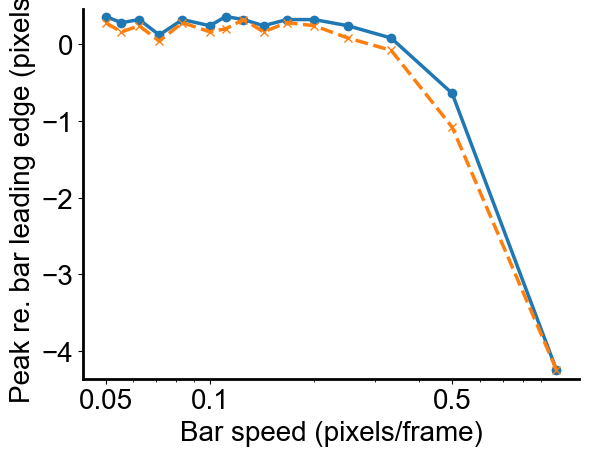

In [26]:
fig = plt.figure()
bar_speedsa = 1/bar_speeds.astype(float)
rel_max_positionsa = np.array(rel_max_positions)
rel_max_positionsa_ablate = np.array(rel_max_positions_ablate)
ax = plt.plot(bar_speedsa,rel_max_positionsa, marker='o')
ax = plt.plot(bar_speedsa,rel_max_positionsa_ablate, marker='x', linestyle='--')
plt.tick_params(axis='both', labelsize=fontsize) 
plt.xscale('log')
plt.xlabel('Bar speed (pixels/frame)',fontsize=fontsize)
plt.ylabel('Peak re. bar leading edge (pixels)',fontsize=fontsize)
plt.grid(False) 
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks([5e-2, 1e-1, 5e-1], ['0.05', '0.1', '0.5'])
plt.ylim(bottom=-4.36, top=0.46)

fig.savefig(f"{root}/figures/supp/anticipation_delay_vs_speed.svg", transparent=False, bbox_inches="tight")
plt.show()